### DEFINITIONS

In [1]:
import os
import time
import pandas as pd
import random
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

def binary_search(tableX, tableY, inputValue):
    low, high = 0, len(tableX) - 1

    while low <= high:
        mid = (low + high) // 2

        if tableX[mid] < inputValue:
            low = mid + 1
        elif tableX[mid] > inputValue:
            high = mid - 1
        else:
            return tableY[mid]  # Exact match, no need for interpolation

    # At this point, 'low' is the index of the smallest entry greater than the temperature
    slope = (tableY[low] - tableY[low - 1]) / (tableX[low] - tableX[low - 1])
    closest_value = tableY[low - 1] + slope * (inputValue - tableX[low - 1])

    return closest_value


### CONFIG

In [2]:
workspace = os.getcwd()
thermoType = 's'

### GENERATE DATA FRAME AND ARRAYS

In [3]:
filename = os.path.join(workspace,f'type_{thermoType}.txt')

# Read the text file
with open(filename, 'r', encoding='latin-1') as file:
    lines = file.readlines()
# Remove lines containing text or unnecessary headers
h1 = 'ITS-90'
h2 =  '°C'
h3 =  'Thermoelectric Voltage in mV'
h4 = '-' # also remove negative temps
lines = [line for line in lines if h1 not in line and h2 not in line and h3 not in line and h4 not in line]

# Identify the end of the table 
end_index = next((i for i, line in enumerate(lines) if line.startswith('*')), None)
# Extract relevant data
data = [line.split() for line in lines[:end_index] if line.strip()]

# Create a DataFrame without specifying column names
df = pd.DataFrame(data)
# Convert values to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Make full voltage and temp arrays
tempTable = []
voltsTable = []
for i in range(len(df)):
    for j in range(1, len(df.columns)):
        temp = df.iloc[i, 0] + (j - 1)
        volts = df.iloc[i,j]
        if not np.isnan(volts):
            tempTable.append(float(temp))
            voltsTable.append(float(volts))

### OPTIMIZE LOOKUP TABLE (DECIMATION) AND GENERATE CSV

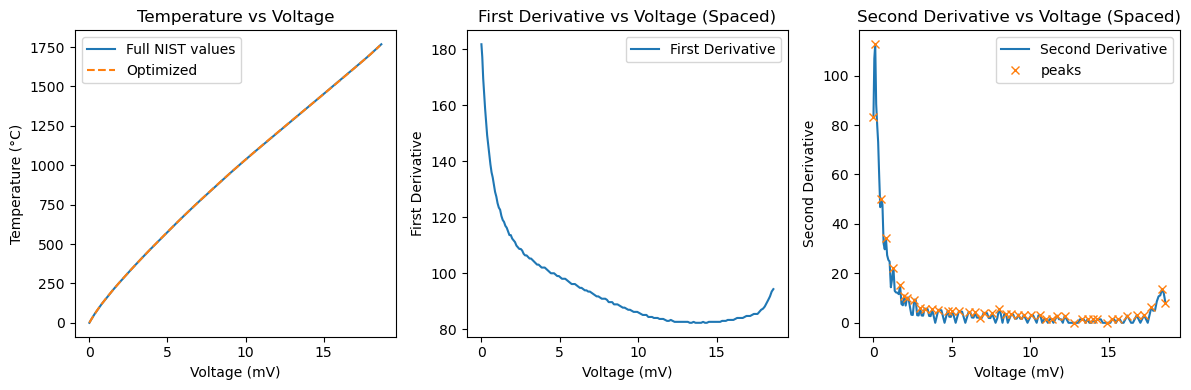

In [4]:
# This method uses find peaks to optimize, could also use lagrange interpolation
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.lagrange.html
# identify non-linear regions to streamline lookup table
x = np.array(voltsTable)
y = np.array(tempTable)
valid_indices = ~np.isnan(x)
x = x[valid_indices]
y = y[valid_indices]

# Spacing for every 10 degrees
x_spaced = x[::11]
y_spaced = y[::11]

# Calculate the first derivative dy/dx
dy_dx = np.gradient(y_spaced, x_spaced)
# Calculate the absolute second derivative d^2y/dx^2
d2y_dx2 = abs(np.gradient(dy_dx, x_spaced))

# Define amounts of points for optimal table
extrema_indices, _ = find_peaks(d2y_dx2)

# Calculate the optimized indices 
extrema_indices = np.concatenate([[0], extrema_indices, [len(x_spaced) - 1]]) 
ib_indices = np.round((extrema_indices[1:] + extrema_indices[:-1]) / 2).astype(int) # inbetween indices
optim_range = np.sort(np.concatenate([extrema_indices,ib_indices]))

# Calculate the optimized indices
# optim_range = np.concatenate([[0], extrema_indices,  [len(x_spaced) - 1]])

# Choose ideal points based on the identified extrema
voltsTable_optim = x_spaced[optim_range]
tempTable_optim = y_spaced[optim_range]

# Save ideal points to CSV
# I decided to not use the df_optim csv as SPIFFS has 1500 kB and saving 10kB/csv is not worth the 0.5degC error IMO
# csv_optim = pd.DataFrame({'Voltage (mV)': voltsTable_optim, 'Temperature (°C)': tempTable_optim})
# csv_optim.to_csv(f'thermocouple_table_{thermoType}.csv', index=False, header=False)
csv = pd.DataFrame({'Voltage (mV)': voltsTable, 'Temperature (°C)': tempTable})
csv.to_csv(f'thermocouple_table_{thermoType}.csv', index=False, header=False)

# Plot x vs y
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(x, y, label='Full NIST values')
plt.plot(voltsTable_optim, tempTable_optim, '--',label='Optimized')
plt.xlabel('Voltage (mV)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature vs Voltage')
plt.legend()

# Plot x vs dy/dx
plt.subplot(1, 3, 2)
plt.plot(x_spaced, dy_dx, label='First Derivative')
plt.xlabel('Voltage (mV)')
plt.ylabel('First Derivative')
plt.title('First Derivative vs Voltage (Spaced)')
plt.legend()

# Plot x vs d^2y/dx^2
plt.subplot(1, 3, 3)
plt.plot(x_spaced, d2y_dx2, label='Second Derivative')
plt.plot(x_spaced[extrema_indices], d2y_dx2[extrema_indices], 'x', label = 'peaks')
plt.xlabel('Voltage (mV)')
plt.ylabel('Second Derivative')
plt.title('Second Derivative vs Voltage (Spaced)')
plt.legend()

plt.tight_layout()
plt.show()

### TESTING

Full Table Approach Time: 472.307205 microseconds
Optimized Table Approach Time: 406.265259 microseconds


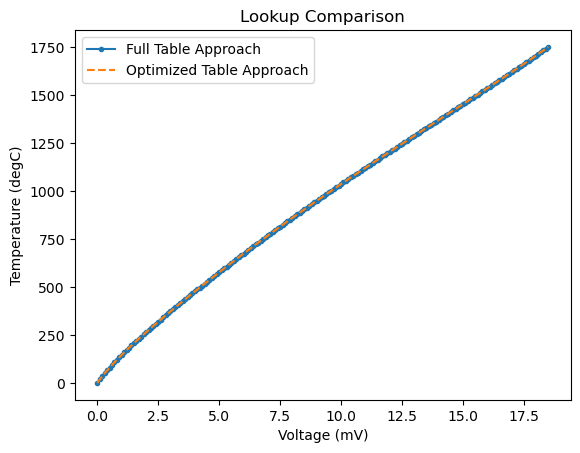

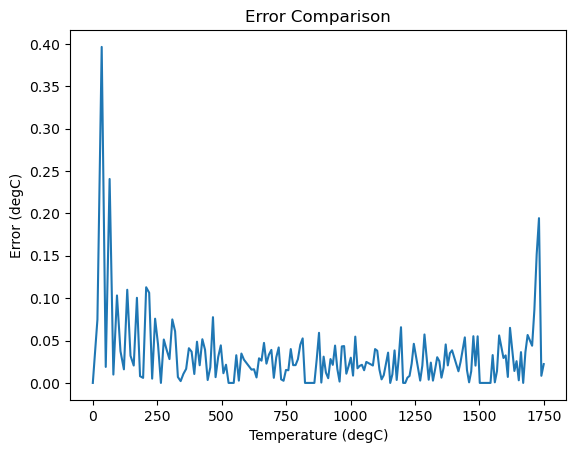

In [5]:
# Here I showcase two differences: time and error
# Time is influenced by binary search algorithm
# Error is influenced by choosing a full table (i.e tempTable) or an optim table (_optim)

temperatureFull = []
temperatureOptim = []

voltage = np.arange (0,18.6,0.1)

# Full table approach
start_time = time.time()
for v in voltage:
    # Full search
    # for i in range(len(tempTable)):
    #     if (voltsTable[i] > v):
    #         slope = (tempTable[i] - tempTable[i-1]) / (voltsTable[i]-voltsTable[i-1])
    #         tfull = tempTable[i-1] + slope * (v - voltsTable[i-1])
    #         break
    # temperatureFull.append(tfull)

    # Binary Search
    temperatureFull.append(binary_search(voltsTable, tempTable, v))

end_time = time.time()
full_table_time = (end_time - start_time) * 1e6  # Convert to microseconds

# Optimized table appraoch
start_time = time.time()
for v in voltage:
    # Full search
    # for i in range(len(tempTable_optim)):
    #     if (voltsTable_optim[i] > v):
    #         slope = (tempTable_optim[i] - tempTable_optim[i-1]) / (voltsTable_optim[i]-voltsTable_optim[i-1])
    #         topt = tempTable_optim[i-1] + slope * (v - voltsTable_optim[i-1])
    #         break    
    # temperatureOptim.append(topt)

    #Binary search
    temperatureOptim.append(binary_search(voltsTable_optim, tempTable_optim, v))
end_time = time.time()
optimized_table_time = (end_time - start_time) * 1e6  # Convert to microseconds


# Print benchmark results
print(f"Full Table Approach Time: {full_table_time:.6f} microseconds")
print(f"Optimized Table Approach Time: {optimized_table_time:.6f} microseconds")

# Plot interpolated thermocouple graphs
plt.plot(voltage, temperatureFull,'.-', label='Full Table Approach')
plt.plot(voltage, temperatureOptim,'--', label='Optimized Table Approach')
plt.xlabel('Voltage (mV)')
plt.ylabel('Temperature (degC)')
plt.title('Lookup Comparison')
plt.legend()
plt.show()

# Plot errors
errorT = np.abs(np.array(temperatureOptim) - np.array(temperatureFull))
plt.plot(temperatureFull, errorT)
plt.xlabel('Temperature (degC)')
plt.ylabel('Error (degC)')
plt.title('Error Comparison')
plt.show()


### RANDOM TESTING

In [7]:
# Generate random milliVoltage
millivolts = random.uniform(0.000, 5.000)
print(f'voltage:{millivolts:.3f} mV\n')

# Find temperature with full table
print('Full table approach')
for i in range(len(tempTable)):
    if (voltsTable[i] > millivolts):
        slope = (tempTable[i] - tempTable[i-1]) / (voltsTable[i]-voltsTable[i-1])
        temperatureFull = tempTable[i-1] + slope * (millivolts - voltsTable[i-1])
        break
print(f'Seeback coefficient: {1/slope:.6f} mV/degC')
print(f'Temperature: {temperatureFull:.3f} degC\n')

# Find temperature with streamlined table
print('Optimized table approach')
for i in range(len(tempTable_optim)):
    if (voltsTable_optim[i] > millivolts):
        slope = (tempTable_optim[i] - tempTable_optim[i-1]) / (voltsTable_optim[i]-voltsTable_optim[i-1])
        temperatureOptim = tempTable_optim[i-1] + slope * (millivolts - voltsTable_optim[i-1])
        break
print(f'Seeback coefficient: {1/slope:.6f} mV/degC')
print(f'Temperature: {temperatureOptim:.3f} degC')
print(f'\nError: {abs(temperatureOptim-temperatureFull):.5f} degC')

voltage:4.225 mV

Full table approach
Seeback coefficient: 0.010000 mV/degC
Temperature: 499.179 degC

Optimized table approach
Seeback coefficient: 0.009933 mV/degC
Temperature: 499.140 degC

Error: 0.03907 degC
